In [33]:
import os
import s3fs
import xarray as xr
import ujson
import dask
import numpy as np
from xmitgcm import llcreader
from fronts.llc.slurp import write_xr

from functools import partial
import matplotlib.pyplot as plt

import matplotlib.cm as cm
from tqdm import tqdm

import cmocean

In [3]:
def _multi_file_closer(closers):
    for closer in closers:
        closer()

In [4]:
# This code will pull data from the remote store created by spencer
# returns a dataset of raw data

def get_remote_llc_data():
    #args :
    var = "Theta,U,V,W,Salt,Eta"
    tstep = 12

    # the model was run with a cadence of 25 seconds. So there are 144 timesteps in an hour.
    tstep_hr = 144
    face_range = range(0,13)
    iter_step = tstep_hr*tstep
    varnames = var.split(',')


    start_from = 1180  # 0 is the first record of Eta, ~1180 is the first record for wind
    #start_from = 1300

    length_in_hours = 12 # total hours to pull data from todo add as input

    start_iter = 10368 + start_from*144
    end_iter = 10368 + start_from*144 + length_in_hours*144
    iter_range = np.arange(start_iter, end_iter, tstep * 144)
    get_Eta_files = True

    endpoint_url = 'https://mghp.osn.xsede.org'
    fs = s3fs.S3FileSystem(anon=True,
                               client_kwargs={'endpoint_url': endpoint_url}
                               )

    if (get_Eta_files):
            filelist = ['cnh-bucket-1/llc_surf/kerchunk_files/llc4320_Eta-U-V-W-Theta-Salt_f' + str(var1) + '_k0_iter_' +
                        str(var) + '.json' for var1 in face_range for var in iter_range]
    else:
            filelist = ['cnh-bucket-1/llc_wind/kerchunk_files/llc4320_KPPhbl-PhiBot-oceTAUX-oceTAUY-SIarea_f' + str(
                var1) + '_k0_iter_' +
                        str(var) + '.json' for var1 in face_range for var in iter_range]

    print(f"Opening {len(filelist)} Kerchunk JSON files...")
    mapper = [fs.open(file, mode='rb') for file in filelist]

    print("Parsing JSON metadata into Python dictionaries...")
    reflist = [ujson.load(mapper1) for mapper1 in mapper]

    open_ = dask.delayed(xr.open_dataset)
    getattr_ = dask.delayed(getattr)

    dict_list = [{
            "storage_options": {"fo": p, "asynchronous": True, "remote_protocol": "s3",
                                "remote_options": {"client_kwargs": {'endpoint_url': endpoint_url},
                                                   "asynchronous": True,
                                                   "anon": True}, #"asynchronous": False
                                },
            "consolidated": False} for p in reflist]

    print("Creating lazy xarray datasets...")
    datasets = [open_("reference://", engine="zarr", backend_kwargs=p, chunks={'i': 720, 'j': 720}) for p in dict_list]
    closers = [getattr_(ds, "_close") for ds in datasets]

    print("Computing delayed datasets (loading metadata lazily)...")
    datasets, closers = dask.compute(datasets, closers)

    print("Combining datasets by coordinates...")
    ds = xr.combine_by_coords([dataset for dataset in datasets], compat="override", coords='minimal',
                                  combine_attrs='override')

    for ds1 in datasets:
            ds1.close()

    ds.set_close(partial(_multi_file_closer, closers))
    print("All datasets combined successfully! Dataset ready for processing.")

    ds = ds.isel(time=0, k=0, k_l=0)
    return ds

ds = get_remote_llc_data()




Opening 13 Kerchunk JSON files...
Parsing JSON metadata into Python dictionaries...
Creating lazy xarray datasets...
Computing delayed datasets (loading metadata lazily)...
Combining datasets by coordinates...
All datasets combined successfully! Dataset ready for processing.


In [5]:
# Now the Grid file!

# code to create a lazily loaded xarray dataset of the llc4320 grid with pointers to the data on OSN
def get_remote_gridfile():
    endpoint_url = 'https://mghp.osn.xsede.org'
    fs = s3fs.S3FileSystem(anon=True,
                               client_kwargs={'endpoint_url': endpoint_url}
                               )

    filelist = ['cnh-bucket-1/llc_surf/kerchunk_files/llc4320_grid_f' + str(var1) + '.json' for var1 in range(0, 13)]

    mapper = [fs.open(file, mode='rb') for file in filelist]

    reflist = [ujson.load(mapper1) for mapper1 in mapper]

    open_ = dask.delayed(xr.open_dataset)
    getattr_ = dask.delayed(getattr)

    dict_list = [{"storage_options": {"fo": p, "asynchronous": True, "remote_protocol": "s3",
                                          "remote_options": {"client_kwargs": {'endpoint_url': endpoint_url},
                                                             "asynchronous": True, "anon": True}}, "consolidated": False} for p in reflist]
    datasets = [open_("reference://", engine="zarr", backend_kwargs=p, chunks={}) for p in dict_list]
    closers = [getattr_(ds, "_close") for ds in datasets]
    datasets, closers = dask.compute(datasets, closers)

    co = xr.combine_by_coords([dataset for dataset in datasets], compat="override", coords='minimal',
                                  combine_attrs='override')

    for ds1 in datasets:
            ds1.close()

    return co

co = get_remote_gridfile()


In [6]:
print(co.coords)

Coordinates:
  * face     (face) int64 104B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * j        (j) int64 35kB 0 1 2 3 4 5 6 ... 4313 4314 4315 4316 4317 4318 4319
  * i        (i) int64 35kB 0 1 2 3 4 5 6 ... 4313 4314 4315 4316 4317 4318 4319
  * j_g      (j_g) int64 35kB 0 1 2 3 4 5 6 ... 4314 4315 4316 4317 4318 4319
  * i_g      (i_g) int64 35kB 0 1 2 3 4 5 6 ... 4314 4315 4316 4317 4318 4319
  * time     (time) datetime64[ns] 82kB 2011-09-13 ... 2012-11-15T15:00:00
    CS       (face, j, i) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    Depth    (face, j, i) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    PHrefC   float32 4B ...
    PHrefF   float32 4B ...
    SN       (face, j, i) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    XC       (face, j, i) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    XG       (face, j_g, i_g) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    YC   

In [8]:
# this function will give us an idea of download times

def estimate_xarray_size(ds):
    total_bytes = 0
    for name, var in tqdm(ds.coords.items(), desc="Estimating memory"):
        if all(dim in ds.dims for dim in var.dims):
            shape = [ds.dims[d] for d in var.dims]
            dtype_size = np.dtype(var.dtype).itemsize
            total_bytes += np.prod(shape) * dtype_size
    for name, var in tqdm(ds.data_vars.items(), desc="Estimating memory"):
        if all(dim in ds.dims for dim in var.dims):
            shape = [ds.dims[d] for d in var.dims]
            dtype_size = np.dtype(var.dtype).itemsize
            total_bytes += np.prod(shape) * dtype_size
    return total_bytes



In [9]:
size_bytes = estimate_xarray_size(co)
print(f"Estimated size grid: {size_bytes/1e9:.2f} GB")

Estimating memory:   0%|          | 0/38 [00:00<?, ?it/s]C:\Users\Jake Tallman\AppData\Local\Temp\ipykernel_3916\749404265.py:7: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  shape = [ds.dims[d] for d in var.dims]
Estimating memory: 100%|██████████| 38/38 [00:00<00:00, 15120.34it/s]
Estimating memory: 0it [00:00, ?it/s]

Estimated size grid: 17.47 GB


In [10]:
size_bytes = estimate_xarray_size(ds)
print(f"Estimated size data: {size_bytes/1e9:.2f} GB")

Estimating memory:   0%|          | 0/11 [00:00<?, ?it/s]C:\Users\Jake Tallman\AppData\Local\Temp\ipykernel_3916\749404265.py:7: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  shape = [ds.dims[d] for d in var.dims]
Estimating memory:   0%|          | 0/6 [00:00<?, ?it/s]C:\Users\Jake Tallman\AppData\Local\Temp\ipykernel_3916\749404265.py:12: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  shape = [ds.dims[d] for d in var.dims]
Estimating memory: 100%|██████████| 6/6 [00:00<00:00, 7691.27it/s]

Estimated size data: 5.82 GB


In [90]:
# For downloading a file

#from dask.diagnostics import ProgressBar
# from dask import compute
#
#
# co_to_load = co.isel(face=slice(0,3), j=slice(None,None,10), i=slice(None,None,10))
# co_to_load = co_to_load[["SN", "hFacC"]]
#
# with ProgressBar():
#     co_compute = co_to_load.compute()
# print(co_compute)

Exploratory Data Analysis!


In [11]:
ds

<xarray.Dataset> Size: 6GB
Dimensions:  (face: 13, j: 4320, i: 4320, i_g: 4320, j_g: 4320, k_p1: 2, k_u: 1)
Coordinates:
  * face     (face) float64 104B 0.0 1.0 2.0 3.0 4.0 ... 8.0 9.0 10.0 11.0 12.0
  * j        (j) float64 35kB 0.0 1.0 2.0 3.0 ... 4.317e+03 4.318e+03 4.319e+03
  * i        (i) float64 35kB 0.0 1.0 2.0 3.0 ... 4.317e+03 4.318e+03 4.319e+03
  * i_g      (i_g) float64 35kB 0.0 1.0 2.0 ... 4.317e+03 4.318e+03 4.319e+03
  * j_g      (j_g) float64 35kB 0.0 1.0 2.0 ... 4.317e+03 4.318e+03 4.319e+03
  * k_p1     (k_p1) float64 16B 0.0 1.0
  * k_u      (k_u) float64 8B 0.0
    k        float64 8B 0.0
    k_l      float64 8B 0.0
    niter    float64 8B dask.array<chunksize=(), meta=np.ndarray>
    time     datetime64[ns] 8B 2011-11-01T04:00:00
Data variables:
    Eta      (face, j, i) float32 970MB dask.array<chunksize=(1, 720, 720), meta=np.ndarray>
    Salt     (face, j, i) float32 970MB dask.array<chunksize=(1, 720, 720), meta=np.ndarray>
    Theta    (face, j, i) float32 970MB dask.array<chunksize=(1, 720, 720), meta=np.ndarray>
    U        (face, j, i_g) float32 970MB dask.array<chunksize=(1, 720, 360), meta=np.ndarray>
    V        (face, j_g, i) float32 970MB dask.array<chunksize=(1, 360, 720), meta=np.ndarray>
    W        (face, j, i) float32 970MB dask.array<chunksize=(1, 720, 720), meta=np.ndarray>
Attributes:
    history:  Created by C. Spencer Jones using https://github.com/cspencerjo...
    source:   MITgcm
    title:    Chunked netcdf created from MITgcm LLC4320 surface output

In [12]:
for name, var in co.coords.items():
    print(f"{name}: {var.shape}")

CS: (13, 4320, 4320)
Depth: (13, 4320, 4320)
PHrefC: ()
PHrefF: ()
SN: (13, 4320, 4320)
XC: (13, 4320, 4320)
XG: (13, 4320, 4320)
YC: (13, 4320, 4320)
YG: (13, 4320, 4320)
Z: ()
Zl: ()
Zp1: ()
Zu: ()
drC: ()
drF: ()
dxC: (13, 4320, 4320)
dxG: (13, 4320, 4320)
dyC: (13, 4320, 4320)
dyG: (13, 4320, 4320)
face: (13,)
hFacC: (13, 4320, 4320)
hFacS: (13, 4320, 4320)
hFacW: (13, 4320, 4320)
i: (4320,)
i_g: (4320,)
j: (4320,)
j_g: (4320,)
k: ()
k_l: ()
k_p1: ()
k_u: ()
niter: (10312,)
rA: (13, 4320, 4320)
rAs: (13, 4320, 4320)
rAw: (13, 4320, 4320)
rAz: (13, 4320, 4320)
rhoRef: ()
time: (10312,)


In [131]:
ds_theta = ds["Theta"]

ds_grid = co

coords_to_keep = ['XC', 'YC', 'dxC', 'dyC', 'dxG', 'dyG', 'rAz', 'rA', 'Depth', 'hFacC', 'SN', 'CS']
ds_grid = ds_grid.reset_coords()[coords_to_keep]

ds_merge = xr.merge([ds_theta, ds_grid])


In [14]:
size_bytes = estimate_xarray_size(ds)
print(f"Estimated size data: {size_bytes/1e9:.2f} GB")

Estimating memory:   0%|          | 0/11 [00:00<?, ?it/s]C:\Users\Jake Tallman\AppData\Local\Temp\ipykernel_3916\749404265.py:7: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  shape = [ds.dims[d] for d in var.dims]
Estimating memory:   0%|          | 0/6 [00:00<?, ?it/s]C:\Users\Jake Tallman\AppData\Local\Temp\ipykernel_3916\749404265.py:12: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  shape = [ds.dims[d] for d in var.dims]
Estimating memory: 100%|██████████| 6/6 [00:00<00:00, 6879.67it/s]

Estimated size data: 5.82 GB


In [24]:
ds_merge

<xarray.Dataset> Size: 14GB
Dimensions:  (face: 13, i: 4320, j: 4320, i_g: 4320, j_g: 4320)
Coordinates:
  * face     (face) float64 104B 0.0 1.0 2.0 3.0 4.0 ... 8.0 9.0 10.0 11.0 12.0
  * i        (i) float64 35kB 0.0 1.0 2.0 3.0 ... 4.317e+03 4.318e+03 4.319e+03
  * j        (j) float64 35kB 0.0 1.0 2.0 3.0 ... 4.317e+03 4.318e+03 4.319e+03
  * i_g      (i_g) int64 35kB 0 1 2 3 4 5 6 ... 4314 4315 4316 4317 4318 4319
  * j_g      (j_g) int64 35kB 0 1 2 3 4 5 6 ... 4314 4315 4316 4317 4318 4319
    k        float64 8B 0.0
    k_l      float64 8B 0.0
    niter    float64 8B dask.array<chunksize=(), meta=np.ndarray>
    time     datetime64[ns] 8B 2011-11-01T04:00:00
Data variables: (12/13)
    Theta    (face, j, i) float32 970MB dask.array<chunksize=(1, 720, 720), meta=np.ndarray>
    XC       (face, j, i) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    YC       (face, j, i) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    dxC      (face, j, i_g) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    dyC      (face, j_g, i) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    dxG      (face, j_g, i) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    ...       ...
    rAz      (face, j_g, i_g) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    rA       (face, j, i) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    Depth    (face, j, i) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    hFacC    (face, j, i) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    SN       (face, j, i) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    maskC    (face, j, i) float64 2GB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
Attributes:
    long_name:      Potential Temperature
    standard_name:  THETA
    units:          degC

In [16]:
ds_merge['maskC'] = xr.where(ds_merge.hFacC > 0, 1, np.nan)
ds_grid['maskC'] = xr.where(ds_merge.hFacC > 0, 1, np.nan)

In [17]:
# # to load in our merged data, I dont know if we need to do this for xarray
#
# from dask.diagnostics import ProgressBar
#
#
# ds_grid_to_load = ds_grid[["SN", "maskC"]]
#
# with ProgressBar():
#     ds_grid_compute = ds_grid_to_load.compute()

In [106]:
# ds_sub_grid = ds_grid_compute.isel(i=slice(None, None, 200), j=slice(None, None, 200))
# ds_merge_sub = ds_merge.isel(i=slice(None, None, 200), j=slice(None, None, 200))

In [88]:
def plot_a_face_by_var(ds, face, color_map=cmocean.cm.thermal, vmin=None, vmax=None):
    # make a ds of this variable
    var = ds[face]

    print(var.dims, var.shape)

    var_slice = var
    print(var_slice.dims, var_slice.shape)
    print("Plotting slice with dims:", var_slice.dims)

    plt.figure(figsize=(20,12)) #cmap=cmocean.cm.thermal

    #var_slice.plot() #(vmin=-5.0, vmax=5.0)
    var_slice.plot.pcolormesh(cmap=color_map, vmin=vmin,vmax=vmax)

    plt.title(f"{VARIABLE}")
    plt.show()

# plot_a_face_by_var(ds_merge.Theta, 0)

In [99]:
def plot_llc_faces_layout(ds, color_map = cmocean.cm.thermal, vmin=None, vmax=None):
    # Layout (row, col) positions of the 13 faces
    layout = {
        0:  (4, 0),
        1:  (3, 0),
        2:  (2, 0),
        3:  (4, 1),
        4:  (3, 1),
        5:  (2, 1),
        6:  (1, 1),
        7:  (1, 2),
        8:  (1, 3),
        9:  (1, 4),
        10: (0, 2),
        11: (0, 3),
        12: (0, 4),
    }

    fig, axes = plt.subplots(5, 5, figsize=(14, 14))
    axes = axes.flatten()

    # hide all axes first
    for ax in axes:
        ax.axis("off")

    mappable = None  # to store color mapping for colorbar

    for face, (row, col) in layout.items():
        var = ds[face]
        ax = axes[row * 5 + col]
        mappable= var.plot(ax=ax, add_colorbar=False, cmap=color_map, vmin=vmin, vmax=vmax)
        ax.set_title(f"Face {face}", fontsize=10)
        ax.axis("off")

    if mappable is not None:
        cbar = fig.colorbar(mappable, ax=axes, orientation="horizontal", fraction=0.05, pad=0.05)
        cbar.set_label(ds.name if hasattr(ds, "name") else "")

    plt.tight_layout()
    plt.show()





In [ ]:
plot_llc_faces_layout(ds_merge.Theta)

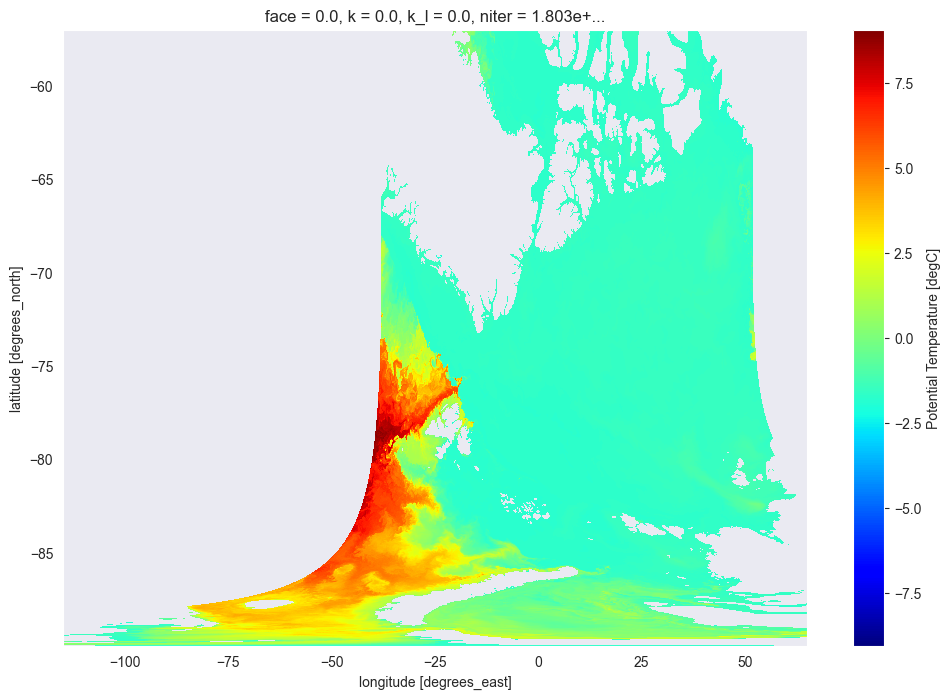

In [122]:
#downsample plotting by real coordinates
i_sub = slice(None, None, 40)
j_sub = slice(None, None, 40)

# Select theta for this face
theta_face = ds_merge.Theta.isel(face=6)

# Assign real coordinates
theta_face = theta_face.assign_coords(x=ds_merge.XC.isel(face=0),
                                      y=ds_merge.YC.isel(face=0))

# Now xarray will use these for plotting
theta_face.plot(x='x', y='y', cmap='jet', figsize=(12,8))

In [ ]:
theta_face.plot

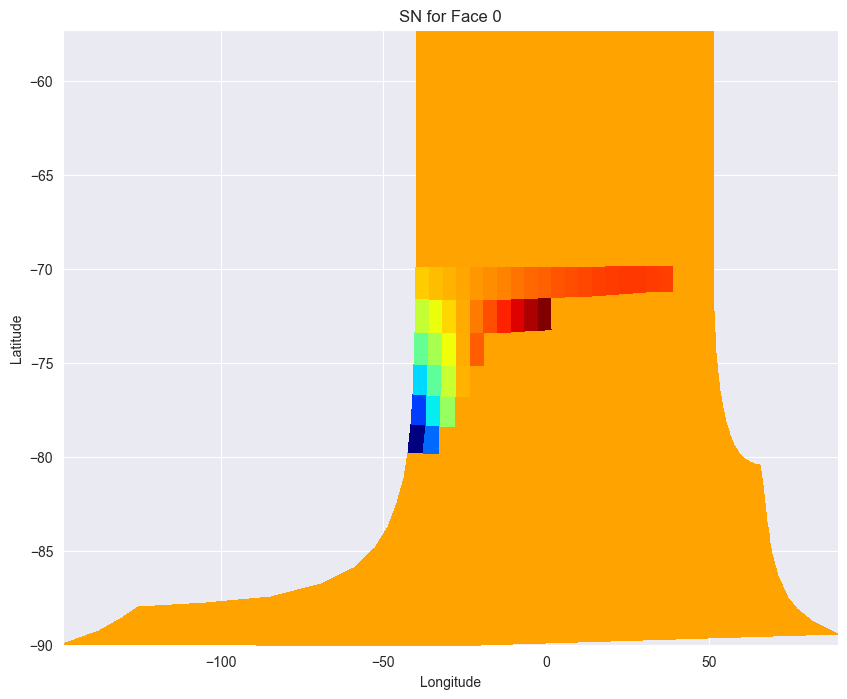

In [107]:
import matplotlib.pyplot as plt

face = 0
plt.figure(figsize=(10, 8))
plt.pcolormesh(ds_merge_sub.XC.isel(face=face),
               ds_merge_sub.YC.isel(face=face),
               ds_merge_sub.SN.isel(face=face),
               cmap='jet', shading='auto')
plt.title(f"SN for Face {face}")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

Calculate Theta Gradient for a face

In [47]:
face = 6
var = "Theta"

In [48]:
var_at_face = ds_merge[var][face]

var_at_face

<xarray.DataArray 'Theta' (j: 4320, i: 4320)> Size: 75MB
dask.array<getitem, shape=(4320, 4320), dtype=float32, chunksize=(720, 720), chunktype=numpy.ndarray>
Coordinates:
  * j        (j) float64 35kB 0.0 1.0 2.0 3.0 ... 4.317e+03 4.318e+03 4.319e+03
  * i        (i) float64 35kB 0.0 1.0 2.0 3.0 ... 4.317e+03 4.318e+03 4.319e+03
    face     float64 8B 6.0
    k        float64 8B 0.0
    k_l      float64 8B 0.0
    niter    float64 8B dask.array<chunksize=(), meta=np.ndarray>
    time     datetime64[ns] 8B 2011-11-01T04:00:00
Attributes:
    long_name:      Potential Temperature
    standard_name:  THETA
    units:          degC

In [55]:
ds_merge

<xarray.Dataset> Size: 14GB
Dimensions:  (face: 13, i: 4320, j: 4320, i_g: 4320, j_g: 4320)
Coordinates:
  * face     (face) float64 104B 0.0 1.0 2.0 3.0 4.0 ... 8.0 9.0 10.0 11.0 12.0
  * i        (i) float64 35kB 0.0 1.0 2.0 3.0 ... 4.317e+03 4.318e+03 4.319e+03
  * j        (j) float64 35kB 0.0 1.0 2.0 3.0 ... 4.317e+03 4.318e+03 4.319e+03
  * i_g      (i_g) int64 35kB 0 1 2 3 4 5 6 ... 4314 4315 4316 4317 4318 4319
  * j_g      (j_g) int64 35kB 0 1 2 3 4 5 6 ... 4314 4315 4316 4317 4318 4319
    k        float64 8B 0.0
    k_l      float64 8B 0.0
    niter    float64 8B dask.array<chunksize=(), meta=np.ndarray>
    time     datetime64[ns] 8B 2011-11-01T04:00:00
Data variables: (12/13)
    Theta    (face, j, i) float32 970MB dask.array<chunksize=(1, 720, 720), meta=np.ndarray>
    XC       (face, j, i) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    YC       (face, j, i) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    dxC      (face, j, i_g) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    dyC      (face, j_g, i) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    dxG      (face, j_g, i) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    ...       ...
    rAz      (face, j_g, i_g) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    rA       (face, j, i) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    Depth    (face, j, i) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    hFacC    (face, j, i) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    SN       (face, j, i) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    maskC    (face, j, i) float64 2GB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
Attributes:
    long_name:      Potential Temperature
    standard_name:  THETA
    units:          degC

In [60]:
    # dfdx = np.gradient(field, axis=1) / dx
    # dfdy = np.gradient(field, axis=0) / dx
    #
    # # Magnitude
    # grad_f2 = dfdx**2 + dfdy**2

#TODO WHAT IS XGCM GRID? WHAT IS DX
import xgcm

grid = xgcm.Grid(ds_grid, periodic=False)

grid
# from ecco_v4_py import get_llc_grid as get_llc_grid
#
# XGCM_grid = get_llc_grid(ds_grid)

<xgcm.Grid>
Y Axis (not periodic, boundary='fill'):
  * center   j --> left
  * left     j_g --> center
X Axis (not periodic, boundary='fill'):
  * center   i --> left
  * left     i_g --> center

In [64]:
#gradient in X

print(f'dxC dimesions: {ds_merge.dxC.dims}')

# step 1
# ... the difference in adjacent grid cells at [i,j] and [i-1, j] in the 'x' direction,
# ... ds denotes the difference in field s
# ... the _hatx suffix denotes that the difference is in the '\hat{x}' direction.
# ... the _M suffix denotes we are working in the model basis
ds_hatx_M = grid.diff(ds_merge.Theta, 'X')

# step 2
# ... divide by the distance between
# ... ds_dx denotes the derivative of field s with respect to distance in meters
# ... the _hatx suffix denotes that the gradient is in the '\hat{x}' direction.
ds_dx_hatx_M = ds_hatx_M / ds_merge.dxC

ds_dx_hatx_M

dxC dimesions: ('face', 'j', 'i_g')
<xarray.DataArray 'Theta' (face: 13, j: 4320, i_g: 4320)> Size: 970MB
dask.array<diff_center_to_left, shape=(13, 4320, 4320), dtype=float32, chunksize=(1, 720, 720), chunktype=numpy.ndarray>
Coordinates:
  * face     (face) float64 104B 0.0 1.0 2.0 3.0 4.0 ... 8.0 9.0 10.0 11.0 12.0
  * j        (j) float64 35kB 0.0 1.0 2.0 3.0 ... 4.317e+03 4.318e+03 4.319e+03
  * i_g      (i_g) int64 35kB 0 1 2 3 4 5 6 ... 4314 4315 4316 4317 4318 4319


<xarray.DataArray (face: 13, j: 4320, i_g: 4320)> Size: 970MB
dask.array<truediv, shape=(13, 4320, 4320), dtype=float32, chunksize=(1, 360, 360), chunktype=numpy.ndarray>
Coordinates:
  * face     (face) float64 104B 0.0 1.0 2.0 3.0 4.0 ... 8.0 9.0 10.0 11.0 12.0
  * j        (j) float64 35kB 0.0 1.0 2.0 3.0 ... 4.317e+03 4.318e+03 4.319e+03
  * i_g      (i_g) int64 35kB 0 1 2 3 4 5 6 ... 4314 4315 4316 4317 4318 4319
    k        float64 8B 0.0
    k_l      float64 8B 0.0
    niter    float64 8B dask.array<chunksize=(), meta=np.ndarray>
    time     datetime64[ns] 8B 2011-11-01T04:00:00

In [65]:
# gradient in y
print(f'dyC dims: {ds_merge.dyC.dims}')

# calculate the gradient of s in 'Y':

# step 1
# ... the difference in adjacent grid cells at [i,j] and [i, j-1] in the 'y' direction,
# ... ds denotes the difference in field s
# ... the _haty suffix denotes that the difference is in the '\hat{y}' direction.
# ... the _M suffix denotes we are working in the model basis
ds_haty_M = grid.diff(ds_merge.Theta, 'Y')

# step 2
# ... divide by the distance between
# ... ds_dx denotes the derivative of field s with respect to distance in meters
# ... the _hatx suffix denotes that the gradient is in the '\hat{y}' direction.
# ... the _M suffix denotes we are working in the model basis
ds_dy_haty_M = ds_haty_M / ds_merge.dyC

print(f'dimensions of ds_haty      : {ds_haty_M.dims}')
print(f'dimensions of ds_dy_haty_M : {ds_dy_haty_M.dims}')

dyC dims: ('face', 'j_g', 'i')
dimensions of ds_haty      : ('face', 'j_g', 'i')
dimensions of ds_dy_haty_M : ('face', 'j_g', 'i')


In [66]:
# Confirm the location of the gradients in 'X' and 'Y' are at the 'u' and 'v' points, respectively.
print(f'ds_dx_hatx_M: {ds_dx_hatx_M.shape, ds_dx_hatx_M.dims}')
print(f'ds_dy_haty_M: {ds_dy_haty_M.shape, ds_dy_haty_M.dims}')

ds_dx_hatx_M: ((13, 4320, 4320), ('face', 'j', 'i_g'))
ds_dy_haty_M: ((13, 4320, 4320), ('face', 'j_g', 'i'))


In [83]:
print(ds_dx_hatx_M[0][0][0].compute().item())

nan


In [84]:
cmap = plt.cm.viridis.copy()            # make a copy of your colormap
cmap.set_bad(color='red')               # NaNs will appear red

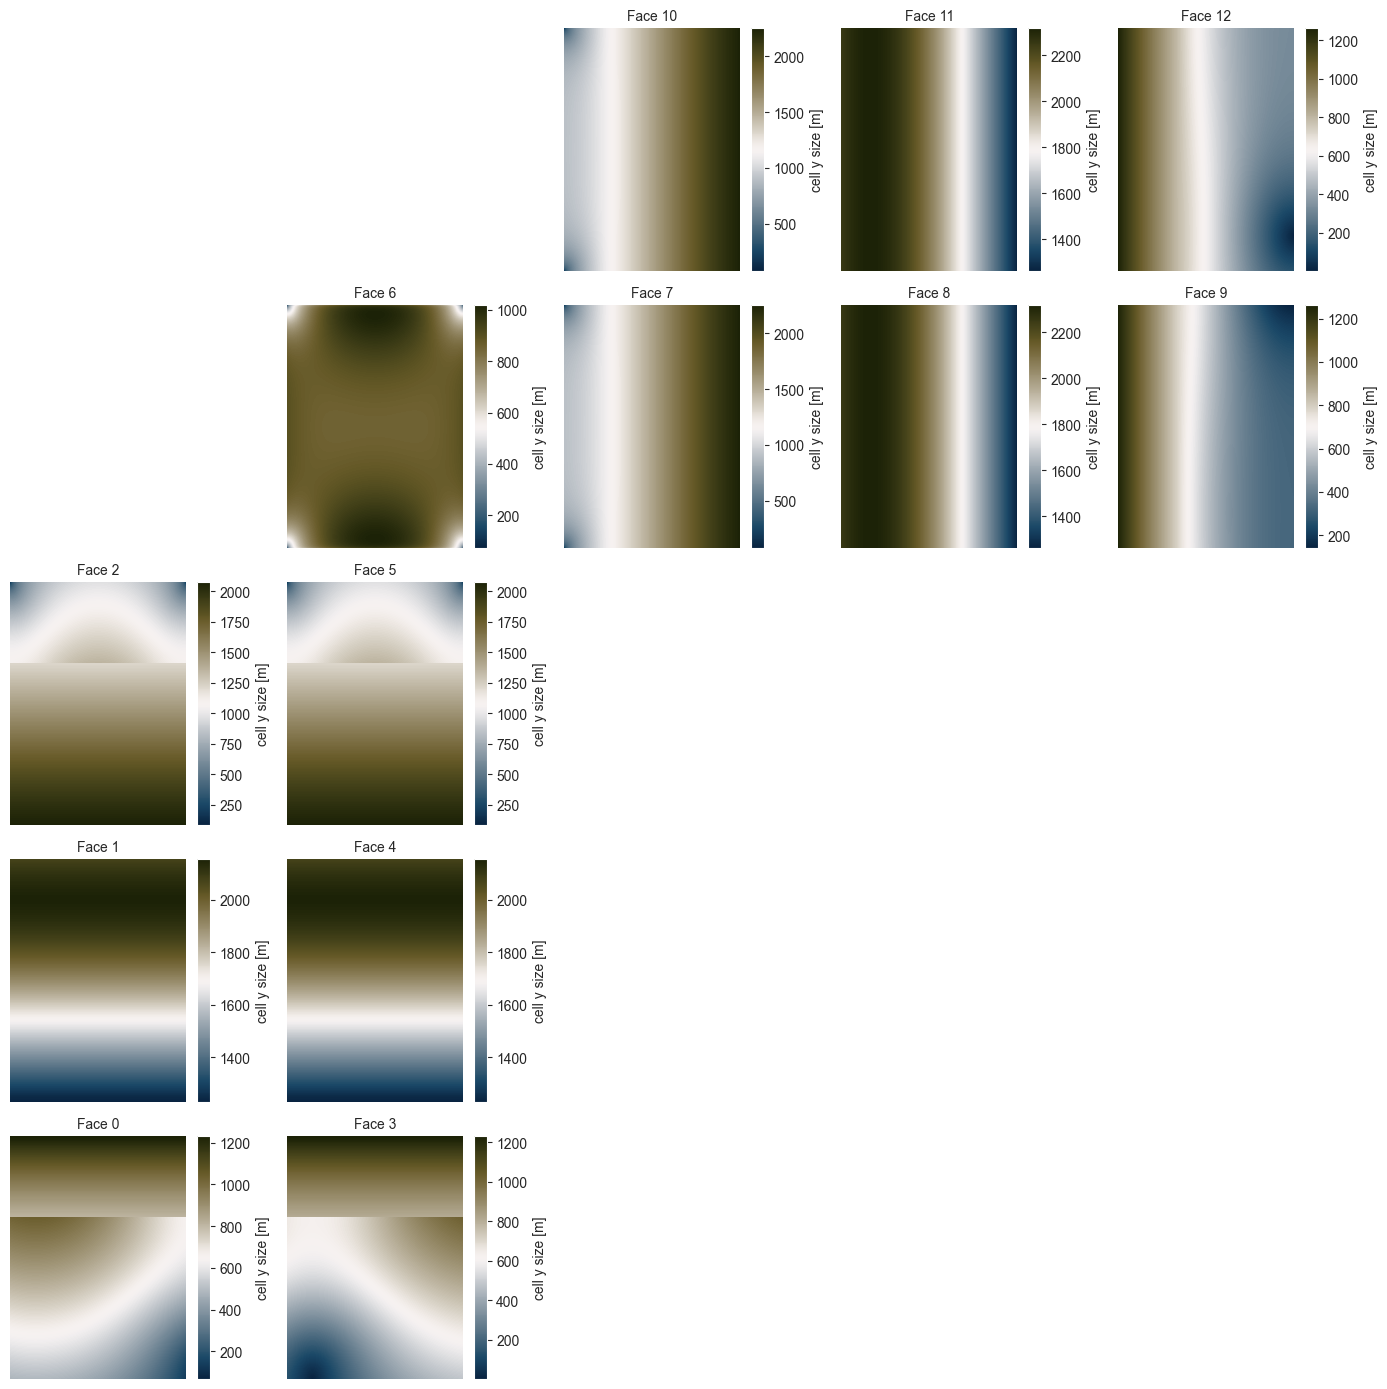

In [94]:
# plod dxc
plot_llc_faces_layout(ds_merge.dyC, cmocean.cm.diff)


In [104]:
min_val = ds_dy_haty_M.min().compute().item()

In [105]:
max_val = ds_dy_haty_M.max().compute().item()

In [106]:
print(min_val)
print(max_val)

-0.013558614999055862
0.014731420204043388


C:\Users\Jake Tallman\AppData\Local\Temp\ipykernel_3916\2564483262.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


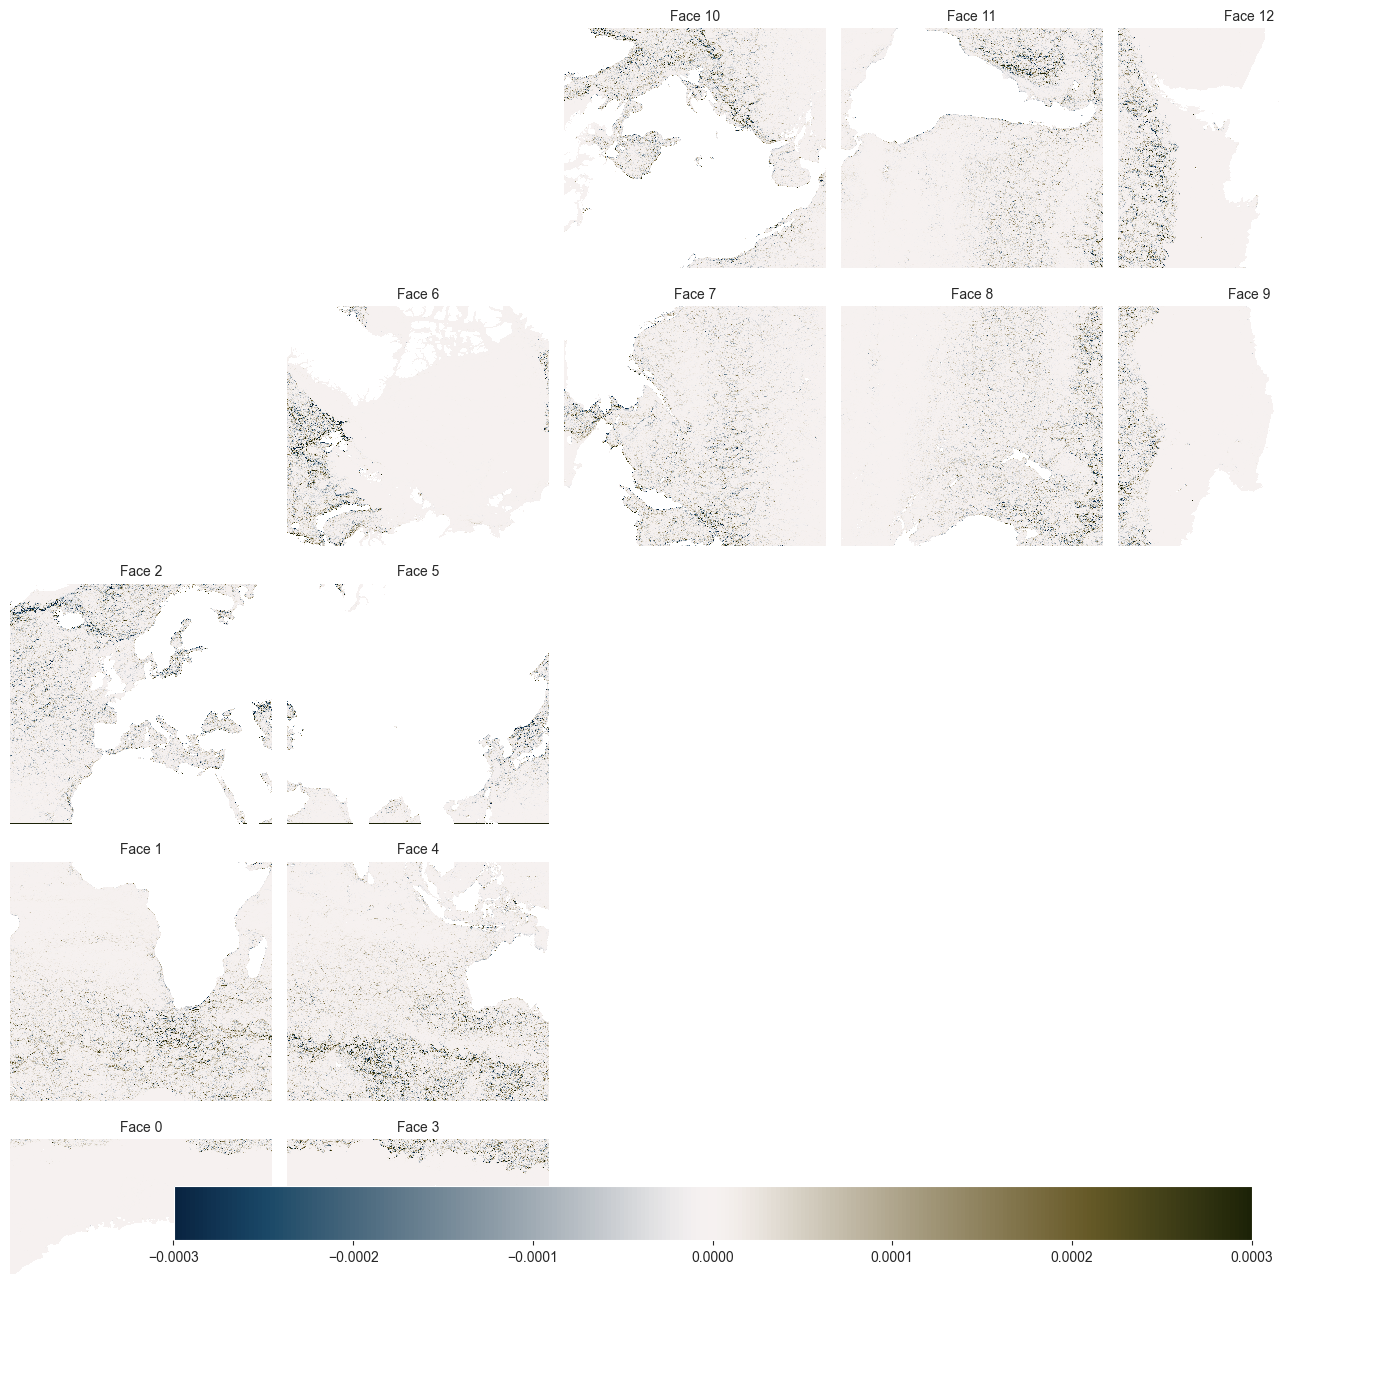

In [108]:
plot_llc_faces_layout(ds_dy_haty_M, cmocean.cm.diff, vmin=-3e-4, vmax=3e-4)

# plot_a_face_by_var(ds_dy_haty_M, 6, cmap, vmin=-3e-6, vmax=3e-6)

Interpolate

In [112]:
print(f'dims of ds_dx_hatx_M: {ds_dx_hatx_M.dims}')
print(f'dims of ds_dy_haty_M: {ds_dy_haty_M.dims}')

dims of ds_dx_hatx_M: ('face', 'j', 'i_g')
dims of ds_dy_haty_M: ('face', 'j_g', 'i')


In [118]:
ds_dx_hatx_M

<xarray.DataArray (face: 13, j: 4320, i_g: 4320)> Size: 970MB
dask.array<truediv, shape=(13, 4320, 4320), dtype=float32, chunksize=(1, 360, 360), chunktype=numpy.ndarray>
Coordinates:
  * face     (face) float64 104B 0.0 1.0 2.0 3.0 4.0 ... 8.0 9.0 10.0 11.0 12.0
  * j        (j) float64 35kB 0.0 1.0 2.0 3.0 ... 4.317e+03 4.318e+03 4.319e+03
  * i_g      (i_g) int64 35kB 0 1 2 3 4 5 6 ... 4314 4315 4316 4317 4318 4319
    k        float64 8B 0.0
    k_l      float64 8B 0.0
    niter    float64 8B dask.array<chunksize=(), meta=np.ndarray>
    time     datetime64[ns] 8B 2011-11-01T04:00:00

In [126]:
grad_s_at_cell_center_X = grid.interp(ds_dx_hatx_M, 'X', boundary='fill')
grad_s_at_cell_center_Y = grid.interp(ds_dy_haty_M, 'Y', boundary='fill')

# grad_s_at_cell_center = xr.merge([grad_s_at_cell_center_X, grad_s_at_cell_center_Y])


# grad_s_at_cell_center = grid.interp_2d_vector({'X': ds_dx_hatx_M, 'Y': ds_dy_haty_M}, boundary='fill')

# print(f'the keys of grad_s_at_cell_center X are {list(grad_s_at_cell_center_X.keys() )}')
# print(f'the keys of grad_s_at_cell_center X are {list(grad_s_at_cell_center_Y.keys() )}')

print(f"\nds_grad_vec X component {grad_s_at_cell_center_X.dims}")
print(f"ds_grad_vec Y component {grad_s_at_cell_center_Y.dims}")


ds_grad_vec X component ('face', 'j', 'i')
ds_grad_vec Y component ('face', 'j', 'i')


In [129]:
ds_grid

<xarray.Dataset> Size: 13GB
Dimensions:  (face: 13, j: 4320, i: 4320, i_g: 4320, j_g: 4320)
Coordinates:
  * face     (face) float64 104B 0.0 1.0 2.0 3.0 4.0 ... 8.0 9.0 10.0 11.0 12.0
  * j        (j) float64 35kB 0.0 1.0 2.0 3.0 ... 4.317e+03 4.318e+03 4.319e+03
  * i        (i) float64 35kB 0.0 1.0 2.0 3.0 ... 4.317e+03 4.318e+03 4.319e+03
  * i_g      (i_g) int64 35kB 0 1 2 3 4 5 6 ... 4314 4315 4316 4317 4318 4319
  * j_g      (j_g) int64 35kB 0 1 2 3 4 5 6 ... 4314 4315 4316 4317 4318 4319
    k        float64 8B 0.0
    k_l      float64 8B 0.0
    niter    float64 8B dask.array<chunksize=(), meta=np.ndarray>
    time     datetime64[ns] 8B 2011-11-01T04:00:00
Data variables:
    XC       (face, j, i) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    YC       (face, j, i) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    dxC      (face, j, i_g) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    dyC      (face, j_g, i) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    dxG      (face, j_g, i) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    dyG      (face, j, i_g) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    rAz      (face, j_g, i_g) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    rA       (face, j, i) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    Depth    (face, j, i) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    hFacC    (face, j, i) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    SN       (face, j, i) float32 970MB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>
    maskC    (face, j, i) float64 2GB dask.array<chunksize=(1, 360, 360), meta=np.ndarray>

Meridional and zonal gradients of theta

In [132]:
# The zonal component of the gradient vector:
# ... the gradient with respect to x in the G basis.
ds_dx_hatx_G  = grad_s_at_cell_center_X*ds_grid['CS'] - \
                grad_s_at_cell_center_Y*ds_grid['SN']

# The meridional component of the gradient vector
# ... the gradient with respect to x in the G basis
ds_dy_haty_G  = grad_s_at_cell_center_X*ds_grid['SN'] + \
                grad_s_at_cell_center_Y*ds_grid['CS']

In [133]:
# update the variable names
ds_dx_hatx_G.name = 'ds_dx_hatx_G'
ds_dy_haty_G.name = 'ds_dy_haty_G'

ds_dx_hatx_G.attrs.update({'long_name':'zonal gradient of SSS'})
ds_dy_haty_G.attrs.update({'long_name':'meridional gradient of SSS'})

#The gradients have units ?/m
ds_dx_hatx_G.attrs.update({'units':'? m-1'})
ds_dy_haty_G.attrs.update({'units':'? m-1'})

In [134]:
print('ds_dx_hatx_G:')
print(f'  dims: {ds_dx_hatx_G.dims}')
print(f'  shape: {ds_dx_hatx_G.shape}')

print('\nds_dy_haty_G:')
print(f'  dims: {ds_dy_haty_G.dims}')
print(f'  shape: {ds_dy_haty_G.shape}')

ds_dx_hatx_G:
  dims: ('face', 'j', 'i')
  shape: (13, 4320, 4320)

ds_dy_haty_G:
  dims: ('face', 'j', 'i')
  shape: (13, 4320, 4320)


In [ ]:
#zonal
plot_llc_faces_layout(ds_dy_haty_G, cmocean.cm.diff, vmin=-1e-6, vmax=1e-6)

Here we calculate gradients using first-order differences:

ds/dx = [s(x+h) - s(x)]/h

with h being the distance between neighboring values of s on the model grid. In practice, we difference adjacent rows or columns of the tile arrays.

The calculate the difference between adjacent rows or columns of ECCO llc tiles we make use of the xgcm ‘diff’ subroutine. After calculating hte differences between adjacent values, we divide by the distances between them.

In the case of scalar fields defined at model tracer points [i,j], the distance between adjacent grid cell centers are provided by the dxC and dyC fields of the ECCO grid dataset, respectively.

See https://xgcm.readthedocs.io/en/latest/api.html#xgcm.Grid.diff for more details about the ‘diff’ function

In [32]:
# !pip install ecco_v4_py

In [41]:
# VARIABLE = "Eta"
#
# # Merge the grid coordinates into ds_rect
# ds_full = ds.copy()
# ds_full["XC"] = co["XC"]
# ds_full["YC"] = co["YC"]
#
# # Now we can access real lat/lon for plotting
# var = ds_full[VARIABLE].isel(time=0, k=0)

In [ ]:
 # MASKS ----------

    # cutout_size = (64, 64)
    #
    # CC_mask_file = os.path.join(os.getenv('OS_OGCM'), 'LLC', 'data', 'CC',
    #                             'LLC_CC_mask_{}.nc'.format(cutout_size[0]))
    #
    # CC_mask = xarray.open_dataset(CC_mask_file)
    #
    # # print(CC_mask)
    # #
    # # print(CC_mask.dims)
    # # print(CC_mask.coords)
    # # print(CC_mask.lon)
    # # print(CC_mask.lat)
    #
    # print(CC_mask.lon.values.min(), CC_mask.lon.values.max())
    # print(CC_mask.lat.values.min(), CC_mask.lat.values.max())
    #
    # print(CC_mask.CC_mask.shape)

In [ ]:


    # PLOT ----------

    # plot before to lat lon

    # VARIABLE = "Eta"
    #
    #
    # ds_rect = llcreader.llcmodel.faces_dataset_to_latlon(ds, metric_vector_pairs=[]) # todo have to update source code for this to work

    # print("\nCOORDINATES RECT:")
    # print(ds_rect)
    # var = ds_rect[VARIABLE]
    #
    # print(var.dims, var.shape)
    # print("Plotting slice with dims:", var.dims)
    #
    # plt.figure(figsize=(20, 12))
    # var.plot(vmin=-5.0, vmax=5.0)
    # plt.title(f"{VARIABLE}")
    # plt.show()